In [1]:
import numpy as np 
import pickle 
import pandas as pd 
from sklearn.metrics import confusion_matrix
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')

In [4]:
path_to_esc_results = Path("esc_analysis")

all_model_results = list(path_to_esc_results.rglob("saved_vars*.pickle"))
# all_model_results

In [10]:
## Get projector sizes from configs 
configs_egs = list(Path('model_configs/barlow_search').glob("*audioset*hparam_set*_lr*.yaml"))

proj_size_dict = {}
for config_path in configs_egs:
    config = yaml.load(open(config_path), Loader=yaml.FullLoader)
    # get hpara_str for mapping
    hpara_str = "base_arch"
    if 'hparam_set' in str(config_path):
        hpara_int = int(re.search(r'hparam_set_(\d+)_', config_path.stem).group(1))
        hpara_str = f"hparam_set_{hpara_int:02d}"
    # get projector size 
    projector_dims = config['model']['arch_kwargs']['projector_dims']
    proj_size_dict[hpara_str] = projector_dims
    

proj_size_dict['base_arch'] = [512, 512]

Text(0.5, 1.01, 'Fits for objective x loss function \n Avgpool')

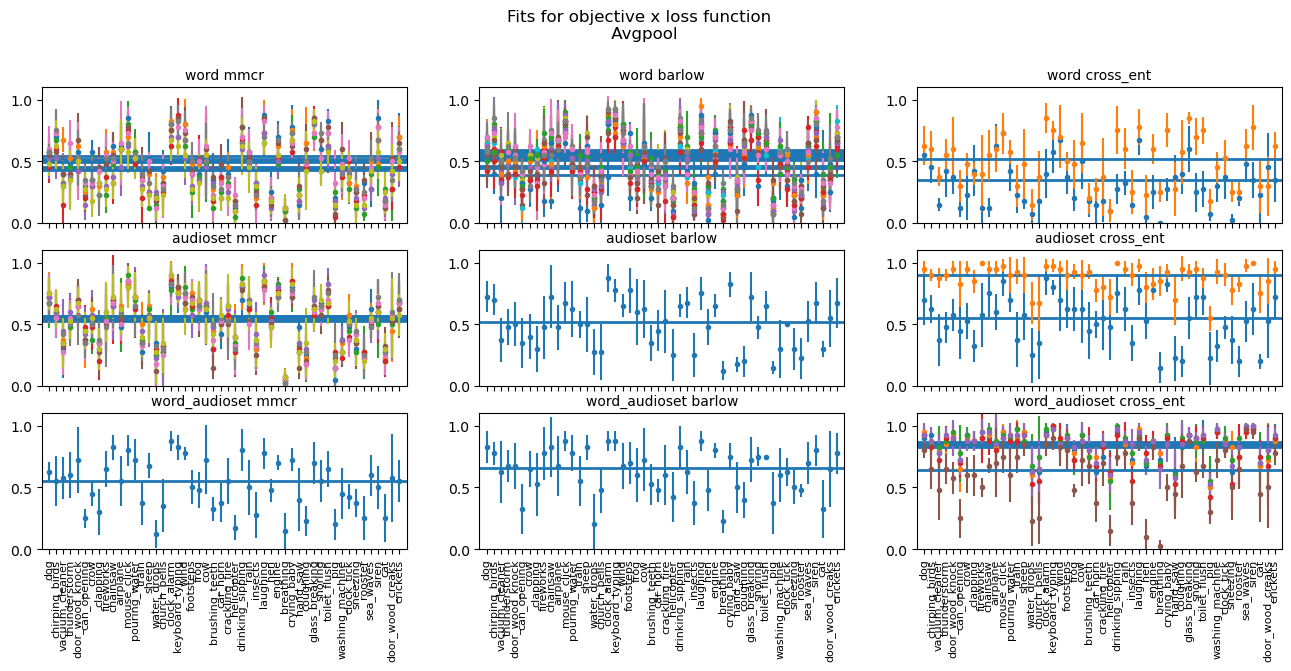

In [5]:
test_layers = [
            'input_after_preproc',
            'conv1',
            'bn1',
            'conv1_relu1',
            'maxpool1',
            'layer1',
            'layer2',
            'layer3',
            'layer4',
            'avgpool',
        ]


def get_category_accuracies(predictions,labels,target):
    """
    Returns the accuracy for target category.
    """
    correct = 0
    total = 0
    for idx in range(len(labels)):
        label = labels[idx]
        if label==target:
            prediction = predictions[idx]
            if label==prediction:
                correct = correct+1
            total = total+1
    return correct/total


def format_model_str(path):
    path_str = str(path)
    task = None
    for task_str in ['word', 'audioset', 'dual', 'word_audioset']:

        if task_str in path_str:
            if task_str == 'dual':
                task = 'word_audioset'
            else:
                task = task_str 
    hpara_str = "base_arch"
    if 'hparam_set' in path_str:
        hpara_int = int(re.search(r'hparam_set_(\d+)_', path_str).group(1))
        hpara_str = f"hparam_set_{hpara_int:02d}"

    loss = [loss for loss in ['mmcr', 'barlow', 'simclr'] if loss in path_str]
    if len(loss) > 0:
        loss = loss[0]
    else:
        loss = 'cross_ent'

    test_layer = [layer for layer in test_layers if layer in path_str][0]

    model_name = f"{task}_{hpara_str}_{loss}_{test_layer}"
    return model_name, task, hpara_str, loss, test_layer


## Get results 
layer_to_plot = 'avgpool'
fig, axs = plt.subplots(3,3, figsize=(16,6), sharex=True)
task_rows = {task:ix for ix,task in enumerate(['word', 'audioset', 'word_audioset'])}
loss_cols = {loss:ix for ix,loss in enumerate(['mmcr', 'barlow', 'cross_ent'])}

for i, results_path in enumerate(all_model_results):

    model_name, task, hpara_str, loss, test_layer = format_model_str(results_path)
    results = pd.read_pickle(results_path)
    if i == 0:
        category_list = np.array(list(results['target_to_category'].values()))
    # print(test_layer)
    
    if 'projects' in str(results_path):
        continue 
    if test_layer != layer_to_plot:
        continue
    category_accuracies = np.stack(results['category_accuracies'], axis=0)
    ## get category mean across splits 
    means = category_accuracies.mean(0)
    # get error (is standard deviation like in original script)
    SEMs = category_accuracies.std(0)
    # overall_acc 
    overall_acc = results['overall_acc']

    row_ix = task_rows[task]
    col_ix = loss_cols[loss]

    axs[row_ix, col_ix].errorbar(np.arange(len(category_list)), means, xerr=0, yerr=SEMs, marker='.', linestyle='None') 
    axs[row_ix, col_ix].axhline(overall_acc, linewidth=2)

    axs[row_ix, col_ix].set_xlim(-1,50)
    axs[row_ix, col_ix].set_ylim(0,1.1)
    axs[row_ix, col_ix].set_title(f"{task} {loss}", fontsize=10)

for i in range(3):
    axs[2, i].set_xticks(np.arange(len(category_list)), category_list, rotation=90, fontsize=8);

plt.suptitle(f'Fits for objective x loss function \n {layer_to_plot.title()}', y = 1.01)

Text(0.5, 1.01, 'Fits for objective x loss function \n Layer2')

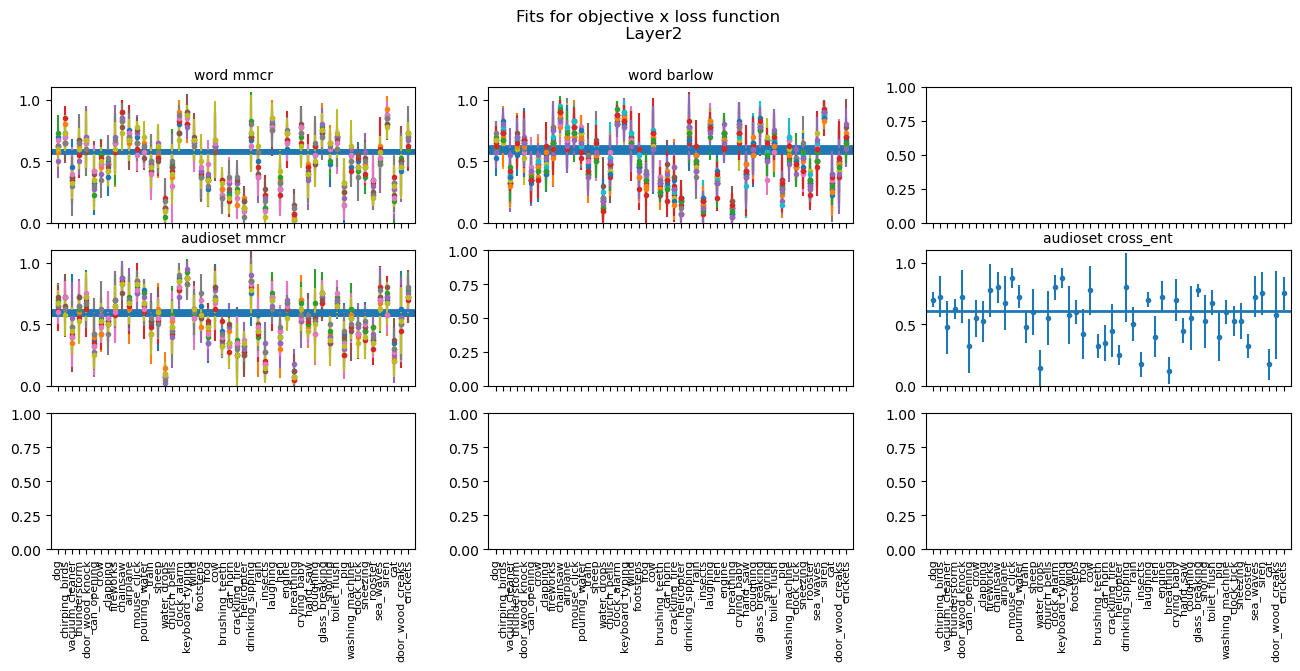

In [6]:
## Get results 
layer_to_plot = 'layer2'

fig, axs = plt.subplots(3,3, figsize=(16,6), sharex=True)
task_rows = {task:ix for ix,task in enumerate(['word', 'audioset', 'word_audioset'])}
loss_cols = {loss:ix for ix,loss in enumerate(['mmcr', 'barlow', 'cross_ent'])}

for i, results_path in enumerate(all_model_results):
    if 'projects' in str(results_path):
        continue 

    model_name, task, hpara_str, loss, test_layer = format_model_str(results_path)
    results = pd.read_pickle(results_path)
    if i == 0:
        category_list = np.array(list(results['target_to_category'].values()))
    # print(test_layer)
    if test_layer != layer_to_plot:
        continue
    category_accuracies = np.stack(results['category_accuracies'], axis=0)
    ## get category mean across splits 
    means = category_accuracies.mean(0)
    # get error (is standard deviation like in original script)
    SEMs = category_accuracies.std(0)
    # overall_acc 
    overall_acc = results['overall_acc']

    row_ix = task_rows[task]
    col_ix = loss_cols[loss]

    axs[row_ix, col_ix].errorbar(np.arange(len(category_list)), means, xerr=0, yerr=SEMs, marker='.', linestyle='None') 
    axs[row_ix, col_ix].axhline(overall_acc, linewidth=2)

    axs[row_ix, col_ix].set_xlim(-1,50)
    axs[row_ix, col_ix].set_ylim(0,1.1)
    axs[row_ix, col_ix].set_title(f"{task} {loss}", fontsize=10)

for i in range(3):
    axs[2, i].set_xticks(np.arange(len(category_list)), category_list, rotation=90, fontsize=8);
plt.suptitle(f'Fits for objective x loss function \n {layer_to_plot.title()}', y = 1.01)


## Plot model summaries - overall vs task, layer size, etc

In [11]:
test_layers = [
            'input_after_preproc',
            'conv1',
            'bn1',
            'conv1_relu1',
            'maxpool1',
            'layer1',
            'layer2',
            'layer3',
            'layer4',
            'avgpool',
        ]
layer_order_dict = {l:i for i,l in enumerate(test_layers)}
df = []
for i, results_path in enumerate(all_model_results):
    if 'projects' in str(results_path):
        continue 
    results = pd.read_pickle(results_path)
    overall_acc = results['overall_acc']

    model_name, task, hpara_str, loss, test_layer = format_model_str(results_path)
    if loss == 'cross_ent':
        proj_dim = 'None'
    else:
        proj_dim = f"{proj_size_dict[hpara_str]}"
    
    data = dict(model_name=model_name, task=task, hpara_str=hpara_str, loss=loss, test_layer=test_layer, overall_acc=overall_acc, proj_dim=proj_dim)
    df.append(data)
df = pd.DataFrame.from_records(df)
df['test_layer'] = df['test_layer'].astype('str')

In [12]:
df[(df.task == 'audioset') & (df.loss == 'cross_ent')]

,model_name,task,hpara_str,loss,test_layer,overall_acc,proj_dim
77,audioset_base_arch_cross_ent_avgpool,audioset,base_arch,cross_ent,avgpool,0.5490,None
87,audioset_base_arch_cross_ent_layer2,audioset,base_arch,cross_ent,layer2,0.6110,None
115,audioset_base_arch_cross_ent_avgpool,audioset,base_arch,cross_ent,avgpool,0.8965,None


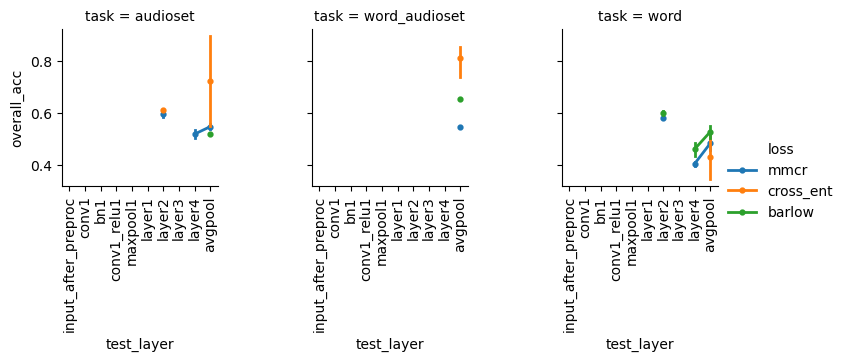

In [13]:
g = sns.catplot(data=df, y='overall_acc', kind='point', x='test_layer', col='task', hue='loss', order=test_layers, height=2.5, linewidth=2,  markersize=3,)
g.set_xticklabels(rotation=90)



In [14]:
proj_sizes = np.array([eval(sizes) if sizes != 'None' else [0, 0] for sizes in df.proj_dim.unique()])
proj_sizes = proj_sizes[proj_sizes[:,1].argsort()]
proj_sizes = proj_sizes[proj_sizes[:,0].argsort(kind='mergesort')]
proj_sizes

# set back to str
sizes_order = ['None' if f"[{sizes[0]}, {sizes[1]}]"=="[0, 0]" else f"[{sizes[0]}, {sizes[1]}]" for sizes in proj_sizes]

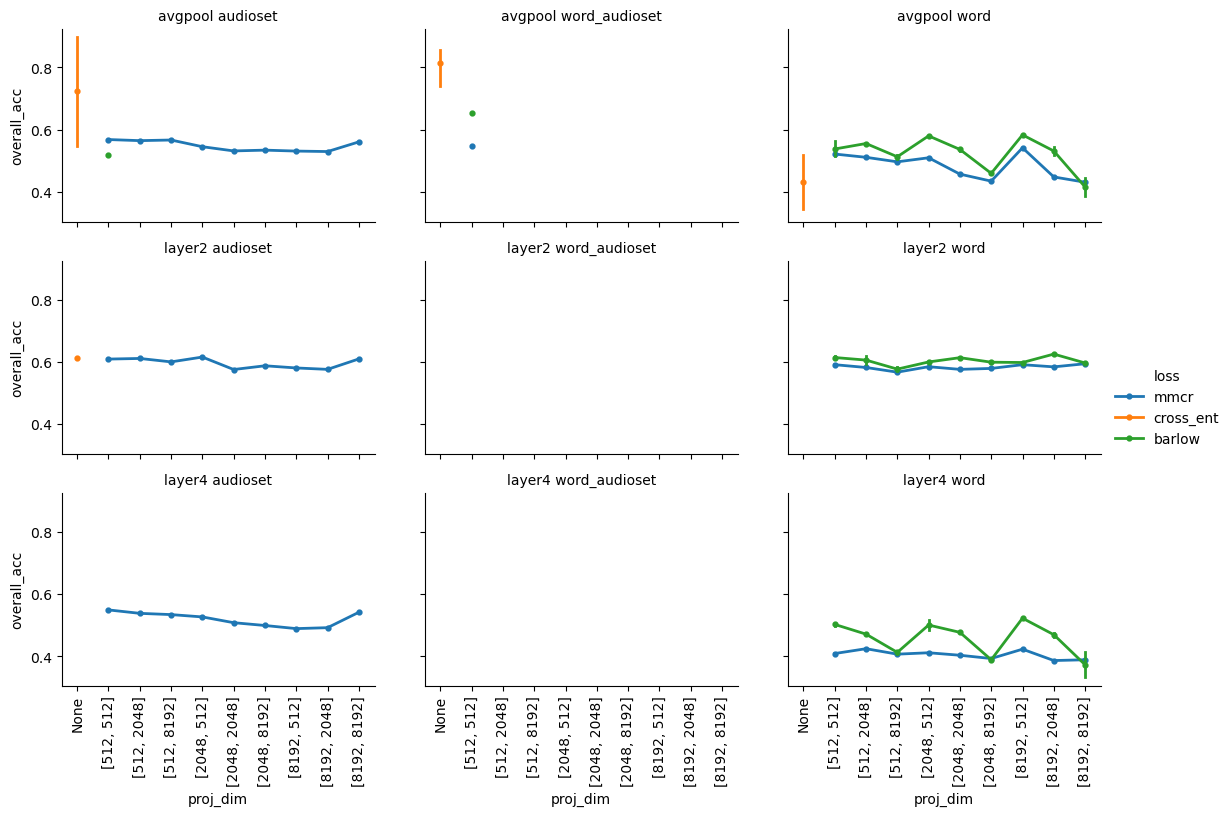

In [15]:


g = sns.catplot(data=df, y='overall_acc', kind='point', x='proj_dim', col='task', hue='loss', row='test_layer', height=2.5, aspect=1.5,  linewidth=2, markersize=3, order=sizes_order)
g.set_xticklabels(sizes_order, rotation=90)

g.set_titles("{row_name} {col_name}")

In [37]:
sorted([(size, acc) for size,acc in df.groupby('proj_dim')['overall_acc'].mean().items()], key=lambda tuple: tuple[1], reverse='True')

[('None', 0.7483333333333333),
 ('[512, 512]', 0.5558571428571428),
 ('[8192, 512]', 0.5470833333333334),
 ('[2048, 512]', 0.5462083333333333),
 ('[512, 2048]', 0.5414583333333334),
 ('[2048, 2048]', 0.5175909090909091),
 ('[512, 8192]', 0.5147916666666666),
 ('[8192, 2048]', 0.5131363636363636),
 ('[2048, 8192]', 0.49733333333333335),
 ('[8192, 8192]', 0.4915)]